### Imports

In [1]:
from lanlab.studies.parametrized_studies.logscore import LogScoreStudy
from lanlab.analyses.logscore.logscore_analysis import LogScoreAnalysis
from lanlab.analyses.logscore.meta_logscore_analysis import MetaLogScoreAnalysis
from lanlab.studies.parametrized_studies.vanilla import VanillaStudy,NewCRTQuestionDataset, OldCRTQuestionDataset,VanillaStudyAlpacaPrompt2,VanillaStudyAlpacaPrompt
from lanlab.data_management.loader.dataset_loader.question_dataset_loader import QuestionDatasetLoader
from lanlab.data_management.loader.sequence_loader.question_loader import QuestionLoader
from lanlab.analyses.accuracy.intuitive_correct_accuracy_analysis import IntuitiveCorrectAccuracyAnalysis
from lanlab.models.hf_models import AutoModel, AutoUnslothModel
import matplotlib.pyplot as plt
import numpy as np
import scipy
import os

### Data Loading

In [2]:
new_crt = NewCRTQuestionDataset()
old_crt = OldCRTQuestionDataset()

In [3]:
#Create paths to models evaluated
path_to_models = 'LLMs' # IF YOU WANT TO RERUN THE EXPERIMENT ON NEW MODELS CHANGE THE PATH HERE / ELSE KEEP IT AS IS IT WILL USE THE ALREADY COMPUTED DATA
model_names = [os.path.join(path_to_models,'llama-7b')]
for _type in ['q','a','qa']:
    for dataset in ['new']:
        for chkp in [407,814,1221]:
            model_names += [os.path.join(path_to_models,'logscores3_'+_type+'_'+dataset+'-checkpoint-'+str(chkp))]
            
model_names += [os.path.join(path_to_models,'logscores3_ref-checkpoint-406'),
                os.path.join(path_to_models,'logscores3_ref-checkpoint-812'),
                os.path.join(path_to_models,'logscores3_ref-checkpoint-1218')]

models = [AutoModel(model_path=model) for model in model_names] #This will load objects corresponding the models but not the models themselves except if the data given in the repo are not found or deleted (see lanlab tutorial)

In [4]:
lsc_studies = {'new':{},
           'old':{}}
v_studies = {'new':{},
             'old':{}}

ref_studies = ['llama-7b','logscores3_ref-checkpoint-406','logscores3_ref-checkpoint-812','logscores3_ref-checkpoint-1218']

new_a = ['llama-7b','logscores3_a_new-checkpoint-407','logscores3_a_new-checkpoint-814','logscores3_a_new-checkpoint-1221']
new_q = ['llama-7b','logscores3_q_new-checkpoint-407','logscores3_q_new-checkpoint-814','logscores3_q_new-checkpoint-1221']
new_qa = ['llama-7b','logscores3_qa_new-checkpoint-407','logscores3_qa_new-checkpoint-814','logscores3_qa_new-checkpoint-1221']

#old_a = ['llama-7b','logscores3_a_old-checkpoint-407','logscores3_a_old-checkpoint-814','logscores3_a_old-checkpoint-1221']
#old_q = ['llama-7b','logscores3_q_old-checkpoint-407','logscores3_q_old-checkpoint-814','logscores3_q_old-checkpoint-1221']
#old_qa = ['llama-7b','logscores3_qa_old-checkpoint-407','logscores3_qa_old-checkpoint-814','logscores3_qa_old-checkpoint-1221']

studies = {'ref_study':ref_studies,'new_a':new_a,'new_q':new_q,'new_qa':new_qa}#,'old_a':old_a,'old_q':old_q,'old_qa':old_qa}

for m in models:
    with m:
        lsc_studies['new'][m.name] = LogScoreStudy(new_crt,m,name='logscores')
        print(lsc_studies['new'][m.name].path)
        lsc_studies['new'][m.name].run()
        lsc_studies['old'][m.name] = LogScoreStudy(old_crt,m,name='logscores')
        print(lsc_studies['old'][m.name].path)
        lsc_studies['old'][m.name].run()
    
        if '1221' in m.name or '1218' in m.name or 'llama' in m.name :
            v_studies['new'][m.name] = VanillaStudy(new_crt,m,qa=False,name='vanilla',reconfigure_model=True,reconfigure_input_collector=True)
            v_studies['new'][m.name]['nb_run_per_question'] = 20
            print(v_studies['new'][m.name].path)
            v_studies['new'][m.name].run()
            v_studies['old'][m.name] = VanillaStudy(old_crt,m,qa=False,name='vanilla',reconfigure_model=True,reconfigure_input_collector=True)
            v_studies['old'][m.name]['nb_run_per_question'] = 20
            print(v_studies['old'][m.name].path)
            v_studies['old'][m.name].run()


data/logscores/llama-7b-new_crt
data/logscores/llama-7b-old_crt
data/vanilla/llama-7b-new_crt
data/vanilla/llama-7b-old_crt
data/logscores/logscores3_q_new-checkpoint-407-new_crt
data/logscores/logscores3_q_new-checkpoint-407-old_crt
data/logscores/logscores3_q_new-checkpoint-814-new_crt
data/logscores/logscores3_q_new-checkpoint-814-old_crt
data/logscores/logscores3_q_new-checkpoint-1221-new_crt
data/logscores/logscores3_q_new-checkpoint-1221-old_crt
data/vanilla/logscores3_q_new-checkpoint-1221-new_crt
data/vanilla/logscores3_q_new-checkpoint-1221-old_crt
data/logscores/logscores3_a_new-checkpoint-407-new_crt
data/logscores/logscores3_a_new-checkpoint-407-old_crt
data/logscores/logscores3_a_new-checkpoint-814-new_crt
data/logscores/logscores3_a_new-checkpoint-814-old_crt
data/logscores/logscores3_a_new-checkpoint-1221-new_crt
data/logscores/logscores3_a_new-checkpoint-1221-old_crt
data/vanilla/logscores3_a_new-checkpoint-1221-new_crt
data/vanilla/logscores3_a_new-checkpoint-1221-old_

In [5]:
def lstrip(l,v,l2=None):
    index = 0
    for i in range(len(l)):
        if l[i] == v:
            pass
        else:
            index = i
            break
    if l2 is None:
        return l[index:]
    return l[index:],l2[index:]

def rstrip(l,v,l2=None):
    index = len(l)
    for i in range(len(l)-1,-1,-1):
        if l[i] == v:
            index = i
        else:
            break
    if l2 is None:
        return l[:index]
    return l[:index],l2[:index]

def strip(tokens,logprobs):
    tokens,logprobs = rstrip(tokens,'<s>',logprobs)
    tokens,logprobs = rstrip(tokens,'<0x0A>',logprobs)
    tokens,logprobs = lstrip(tokens,'<s>',logprobs)
    return tokens,logprobs

def init_sequence(seq):
    """ Replace the first logprob by 0 """
    return np.concatenate([[0],np.array(seq[1:])])

def plot_loggraph(logprobs,tokens=None,normalize=False,color=None,ax=None,label=None):
    """ Plot the loggraph of the sequence """
    #Set the first token prob to 0
    #tokens,logprobs = strip(tokens,logprobs)
    if ax is None:
        ax = plt.gca()
    _logprobs = init_sequence(logprobs)
    #Set x and y for plotting
    x = np.array(range(len(_logprobs)))
    y = np.cumsum(_logprobs)
    if normalize:
        x = x/len(x)
        y = y/len(x)
    #Plotting
    ax.plot(x,y,color=color,label=label)
    #Legends
    ax.set_xticks(x)
    ax.set_xlabel('Token indexs',fontsize=12)
    if not(tokens is None):
        ax.set_xticklabels(tokens,rotation=90,fontsize=12)
        ax.set_xlabel('Tokens',fontsize=12)
    ax.tick_params(axis='y',labelsize=12)
    ax.set_ylabel('Cumulative logprobability',fontsize=12)
    

### Paper Figures

#### Figure 2 - up

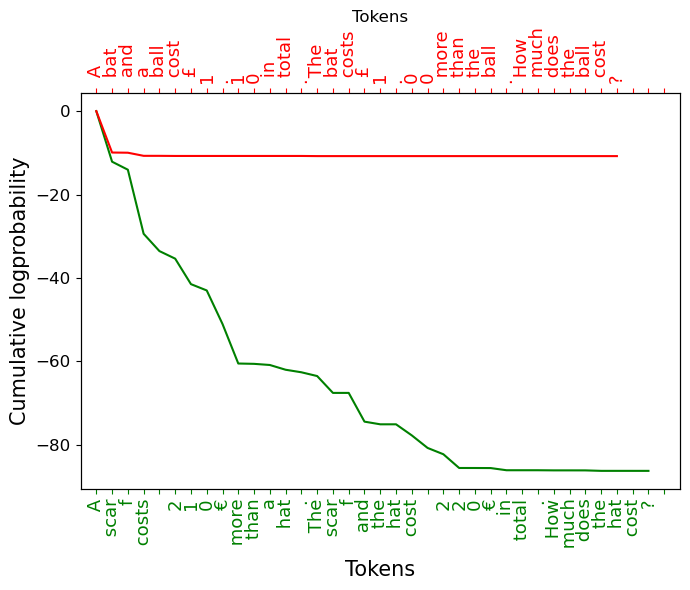

In [6]:
%matplotlib inline

index = 0

fig = plt.figure(figsize=(7,6))
ax = plt.gca()
logp1 = lsc_studies['new']['llama-7b'].data[index,0][0]['logp']
tokens1 = lsc_studies['new']['llama-7b'].data[index,0][0]['tokens']
tokens1,logp1 = strip(tokens1,logp1)
ax.xaxis.tick_top()

ax2 = ax.twiny()
logp2 = lsc_studies['old']['llama-7b'].data[index,0][0]['logp']
tokens2 = lsc_studies['old']['llama-7b'].data[index,0][0]['tokens']
tokens2,logp2 = strip(tokens2,logp2)

x1 = np.arange(len(tokens1))
x2 = np.arange(len(tokens2))
y1 = np.cumsum(np.sort(init_sequence(logp1))[::-1])
y2 = np.cumsum(np.sort(init_sequence(logp2))[::-1])

if len(logp1) > len(logp2):
    tokens2 += ['']*(len(logp1)-len(logp2))
    logp2 += [np.nan]*(len(logp1)-len(logp2))
    
if len(logp2) > len(logp1):
    tokens1 += ['']*(len(logp2)-len(logp1))
    logp1 += [np.nan]*(len(logp2)-len(logp1))

#plt.plot(x1,y1,color='green',alpha=0.5,ls='--')
plot_loggraph(logp1,tokens=tokens1,color='green',ax=ax)
#plt.fill_between(x1,y1,color='green',alpha=0.1)
ax.tick_params(axis='x', colors='green')
ax.set_xticklabels(tokens1,fontsize=13)

#plt.plot(x2,y2,color='red',alpha=0.5,ls='--')
plot_loggraph(logp2,tokens=tokens2,color='red',ax=ax2)
#plt.fill_between(x2,y2,color='red',alpha=0.1)
ax2.tick_params(axis='x', colors='red')
ax2.set_xticklabels(tokens2,fontsize=13)

# Synchronize limits and ticks
ax.set_xlim(-1, max(len(logp1), len(logp2))+1)
ax2.set_xlim(-1, max(len(logp1), len(logp2))+1)

ax.set_xticks(range(max(len(logp1), len(logp2))+1))
ax2.set_xticks(range(max(len(logp1), len(logp2))+1))

ax.set_xlabel('Tokens',fontsize=15)
ax.set_ylabel('Cumulative logprobability', fontsize=15)

#ax.set_xticks(range(len(logp1)))
#ax2.set_xticks(range(len(logp2)))
plt.tight_layout()
plt.savefig('figures/fig1A.svg')

plt.show()

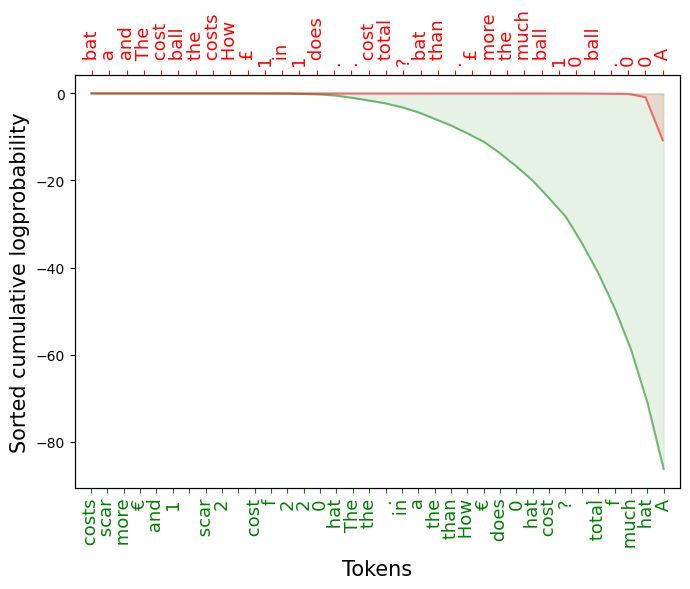

In [7]:
%matplotlib inline

index = 0

fig = plt.figure(figsize=(7,6))
ax = plt.gca()
logp1 = lsc_studies['new']['llama-7b'].data[index,0][0]['logp']
tokens1 = lsc_studies['new']['llama-7b'].data[index,0][0]['tokens']
tokens1,logp1 = strip(tokens1,logp1)
ax.xaxis.tick_top()

ax2 = ax.twiny()
logp2 = lsc_studies['old']['llama-7b'].data[index,0][0]['logp']
tokens2 = lsc_studies['old']['llama-7b'].data[index,0][0]['tokens']
tokens2,logp2 = strip(tokens2,logp2)

x1 = np.arange(len(tokens1))
seq1 = init_sequence(logp1)
order1 = np.argsort(seq1)

x2 = np.arange(len(tokens2))
seq2 = init_sequence(logp2)
order2 = np.argsort(seq2)

y1 = np.cumsum(seq1[order1][::-1])
y2 = np.cumsum(seq2[order2][::-1])

tokens1= np.array(tokens1)
tokens1 = tokens1[order1]
tokens2 = np.array(tokens2)
tokens2 = tokens2[order2]

#if len(logp1) > len(logp2):
#    tokens2 += ['']*(len(logp1)-len(logp2))
#    logp2 += [np.nan]*(len(logp1)-len(logp2))
    
#if len(logp2) > len(logp1):
#    tokens1 += ['']*(len(logp2)-len(logp1))
#    logp1 += [np.nan]*(len(logp2)-len(logp1))

# Synchronize limits and ticks
ax.set_xlim(-1,len(logp1))
ax2.set_xlim(-1,len(logp2))

ax.set_xticks(range(len(logp1)))
ax2.set_xticks(range(len(logp2)))

ax.plot(x1,y1,color='green',alpha=0.5)
#plot_loggraph(logp1,tokens=tokens1,color='green',ax=ax)
ax.fill_between(x1,y1,color='green',alpha=0.1)
ax.tick_params(axis='x', colors='green')
ax.set_xticklabels(tokens1.tolist(),fontsize=13,rotation='vertical')

ax2.plot(x2,y2,color='red',alpha=0.5)
#plot_loggraph(logp2,tokens=tokens2,color='red',ax=ax2)
ax2.fill_between(x2,y2,color='red',alpha=0.1)
ax2.tick_params(axis='x', colors='red')
ax2.set_xticklabels(tokens2.tolist(),fontsize=13,rotation='vertical')

ax.set_xlabel('Tokens',fontsize=15)
ax.set_ylabel('Sorted cumulative logprobability', fontsize=15)

#ax.set_xticks(range(len(logp1)))
#ax2.set_xticks(range(len(logp2)))
plt.tight_layout()
plt.savefig('figures/fig1B.svg')

plt.show()

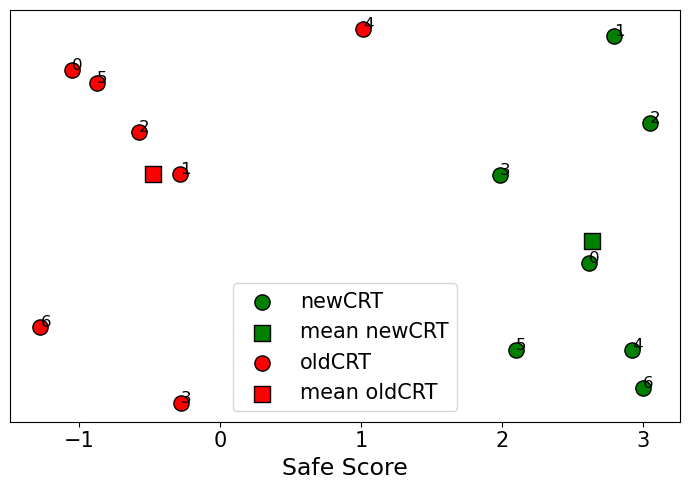

In [8]:
fig,ax = plt.subplots(figsize=(7,5))
np.random.seed(42)


for i,dataset in enumerate(['new','old']):
    s = LogScoreAnalysis(lsc_studies[dataset]['llama-7b'])
    params0 = np.log(-np.array([s.data[qi][2] for qi in range(len(s.data))]))
    params1 = np.array([np.random.random() for qi in range(len(s.data))])
    #print(dataset,params0,params1)

    color = 'red'
    if i == 0:
        color = 'green'

    sc1 = plt.scatter(params0,params1,c=color,edgecolor='black',label=dataset+'CRT',s=120)
    plt.scatter([np.mean(params0)],[np.mean(params1)],c=color,marker='s',edgecolor='black',label='mean '+dataset+'CRT',s=120)
    
    
    for i,(x,y) in enumerate(zip(params0,params1)):
        plt.annotate(str(i),(x,y),fontsize=12)

#plt.xscale('log')
#plt.yscale('log')

plt.xlabel('Safe Score',fontsize=17)
plt.ylabel('',fontsize=17)
plt.yticks([])
plt.gca().tick_params(axis='x',labelsize=15)
plt.gca().tick_params(axis='y',labelsize=15)
                 
plt.legend(loc='best',ncol=1,fontsize=15)
plt.tight_layout()
plt.savefig('figures/fig1C.svg')


Ttest_indResult(statistic=-9.442839904943185, pvalue=3.80465712644255e-06)
-0.47483327283931454 7
2.636574905457203


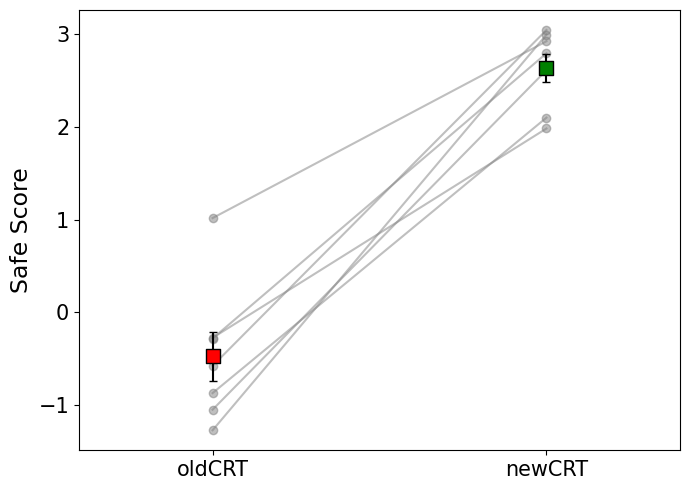

In [9]:
fig,ax = plt.subplots(figsize=(7,5))

snew = LogScoreAnalysis(lsc_studies['new']['llama-7b'])
sold = LogScoreAnalysis(lsc_studies['old']['llama-7b'])

for param_id in [0]:
    paramsnew = np.log(-np.array([snew.data[qi][2] for qi in range(len(snew.data))]))
    paramsold = np.log(-np.array([sold.data[qi][2] for qi in range(len(sold.data))]))
    
    color = 'red'
    if i == 0:
        color = 'green'

    for i in range(len(paramsnew)):
        plt.plot([0,1],[paramsold[i],paramsnew[i]],marker='o',c='grey',zorder=0,alpha=0.5)

    plt.scatter([0],[np.mean(paramsold)],c='red',marker='s',s=100,edgecolor='black',label='mean old CRT',zorder=1)
    plt.scatter([1],[np.mean(paramsnew)],c='green',marker='s',s=100,edgecolor='black',label='mean new CRT',zorder=1)

    plt.errorbar([0],[np.mean(paramsold)],yerr=[np.std(paramsold)/len(paramsold)**0.5],marker='o', capsize=3,c='black',zorder=0)
    plt.errorbar([1],[np.mean(paramsnew)],yerr=[np.std(paramsnew)/len(paramsnew)**0.5],marker='o',capsize=3,c='black',zorder=0)

#print(paramsold)
#print(paramsnew)
print(scipy.stats.ttest_ind(paramsold,paramsnew,equal_var=False))
print(np.mean(paramsold),len(paramsold))
print(np.mean(paramsnew))
    
#plt.yscale('log')
plt.gca().set_xticks([0,1])
plt.gca().set_xticklabels(['oldCRT','newCRT'])
plt.ylabel('Safe Score',fontsize=17)

plt.gca().tick_params(axis='x',labelsize=15)
plt.gca().tick_params(axis='y',labelsize=15)

plt.xlim(-0.4,1.4)

plt.tight_layout()
plt.savefig('figures/fig1D.svg')

#### Figure 2 - bottom

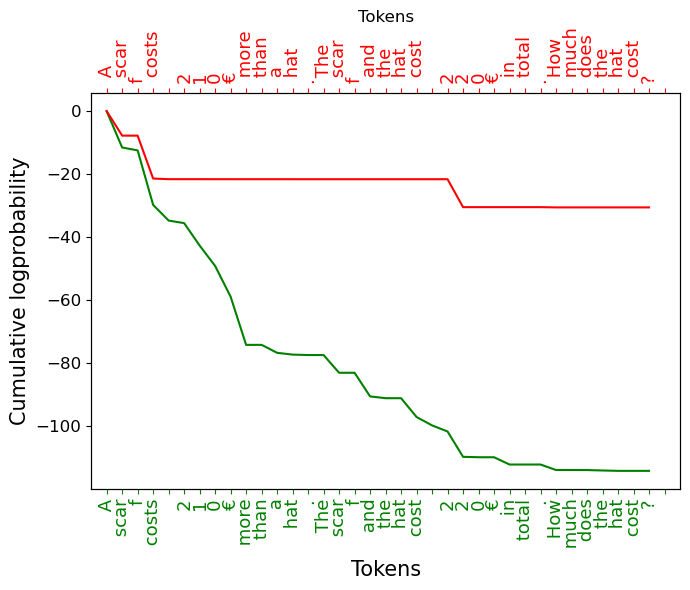

In [10]:
%matplotlib inline

fig = plt.figure(figsize=(7,6))
ax = plt.gca()
logp1 = lsc_studies['new']['logscores3_ref-checkpoint-1218'].data[0,0][0]['logp']
tokens1 = lsc_studies['new']['logscores3_ref-checkpoint-1218'].data[0,0][0]['tokens']
tokens1,logp1 = strip(tokens1,logp1)
ax.xaxis.tick_top()

ax2 = ax.twiny()
logp2 = lsc_studies['new']['logscores3_qa_new-checkpoint-1221'].data[0,0][0]['logp']
tokens2 = lsc_studies['new']['logscores3_qa_new-checkpoint-1221'].data[0,0][0]['tokens']
tokens2,logp2 = strip(tokens2,logp2)

x1 = np.arange(len(tokens1))
x2 = np.arange(len(tokens2))
y1 = np.cumsum(np.sort(init_sequence(logp1))[::-1])
y2 = np.cumsum(np.sort(init_sequence(logp2))[::-1])

if len(logp1) > len(logp2):
    tokens2 += ['']*(len(logp1)-len(logp2))
    logp2 += [np.nan]*(len(logp1)-len(logp2))
    
if len(logp2) > len(logp1):
    tokens1 += ['']*(len(logp2)-len(logp1))
    logp1 += [np.nan]*(len(logp2)-len(logp1))

#plt.plot(x1,y1,color='green',alpha=0.5,ls='--')
plot_loggraph(logp1,tokens=tokens1,color='green',ax=ax)
#plt.fill_between(x1,y1,color='green',alpha=0.1)
ax.tick_params(axis='x', colors='green')
ax.set_xticklabels(tokens1,fontsize=13)

#plt.plot(x2,y2,color='red',alpha=0.5,ls='--')
plot_loggraph(logp2,tokens=tokens2,color='red',ax=ax2)
#plt.fill_between(x2,y2,color='red',alpha=0.1)
ax2.tick_params(axis='x', colors='red')
ax2.set_xticklabels(tokens2,fontsize=13)



# Synchronize limits and ticks
ax.set_xlim(-1, max(len(logp1), len(logp2))+1)
ax2.set_xlim(-1, max(len(logp1), len(logp2))+1)

ax.set_xticks(range(max(len(logp1), len(logp2))+1))
ax2.set_xticks(range(max(len(logp1), len(logp2))+1))

ax.set_xlabel('Tokens',fontsize=15)
ax.set_ylabel('Cumulative logprobability', fontsize=15)

#ax.set_xticks(range(len(logp1)))
#ax2.set_xticks(range(len(logp2)))
plt.tight_layout()
plt.savefig('figures/fig2A.svg')

plt.show()

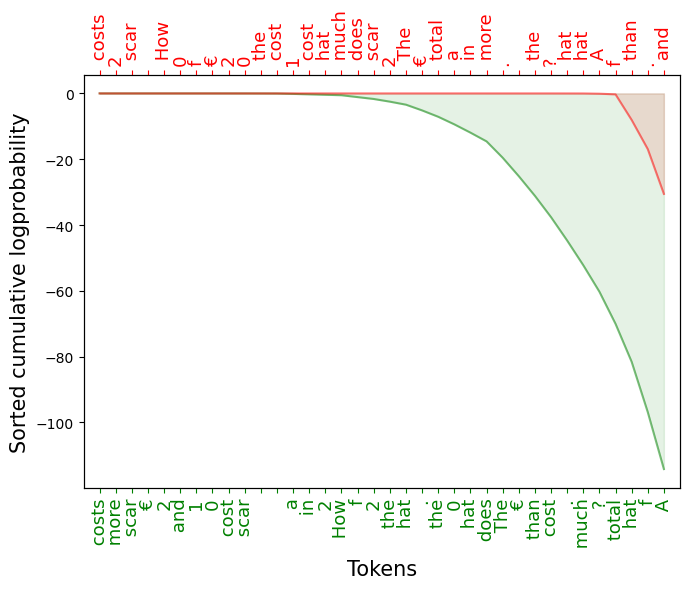

In [11]:
%matplotlib inline

index = 0

fig = plt.figure(figsize=(7,6))
ax = plt.gca()
logp1 = lsc_studies['new']['logscores3_ref-checkpoint-1218'].data[0,0][0]['logp']
tokens1 = lsc_studies['new']['logscores3_ref-checkpoint-1218'].data[0,0][0]['tokens']
tokens1,logp1 = strip(tokens1,logp1)
ax.xaxis.tick_top()

ax2 = ax.twiny()
logp2 = lsc_studies['new']['logscores3_qa_new-checkpoint-1221'].data[0,0][0]['logp']
tokens2 = lsc_studies['new']['logscores3_qa_new-checkpoint-1221'].data[0,0][0]['tokens']
tokens2,logp2 = strip(tokens2,logp2)

x1 = np.arange(len(tokens1))
seq1 = init_sequence(logp1)
order1 = np.argsort(seq1)

x2 = np.arange(len(tokens2))
seq2 = init_sequence(logp2)
order2 = np.argsort(seq2)

y1 = np.cumsum(seq1[order1][::-1])
y2 = np.cumsum(seq2[order2][::-1])

tokens1= np.array(tokens1)
tokens1 = tokens1[order1]
tokens2 = np.array(tokens2)
tokens2 = tokens2[order2]

#if len(logp1) > len(logp2):
#    tokens2 += ['']*(len(logp1)-len(logp2))
#    logp2 += [np.nan]*(len(logp1)-len(logp2))
    
#if len(logp2) > len(logp1):
#    tokens1 += ['']*(len(logp2)-len(logp1))
#    logp1 += [np.nan]*(len(logp2)-len(logp1))

# Synchronize limits and ticks
ax.set_xlim(-1,len(logp1))
ax2.set_xlim(-1,len(logp2))

ax.set_xticks(range(len(logp1)))
ax2.set_xticks(range(len(logp2)))

ax.plot(x1,y1,color='green',alpha=0.5)
#plot_loggraph(logp1,tokens=tokens1,color='green',ax=ax)
ax.fill_between(x1,y1,color='green',alpha=0.1)
ax.tick_params(axis='x', colors='green')
ax.set_xticklabels(tokens1.tolist(),fontsize=13,rotation='vertical')

ax2.plot(x2,y2,color='red',alpha=0.5)
#plot_loggraph(logp2,tokens=tokens2,color='red',ax=ax2)
ax2.fill_between(x2,y2,color='red',alpha=0.1)
ax2.tick_params(axis='x', colors='red')
ax2.set_xticklabels(tokens2.tolist(),fontsize=13,rotation='vertical')

ax.set_xlabel('Tokens',fontsize=15)
ax.set_ylabel('Sorted cumulative logprobability', fontsize=15)

#ax.set_xticks(range(len(logp1)))
#ax2.set_xticks(range(len(logp2)))
plt.tight_layout()
plt.savefig('figures/fig2B.svg')

plt.show()

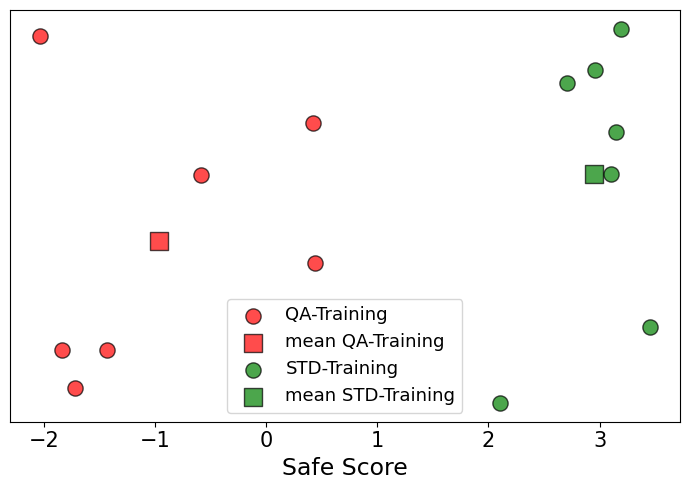

In [12]:
fig,ax = plt.subplots(figsize=(7,5))
np.random.seed(42)


for i,model in enumerate(['logscores3_qa_new-checkpoint-1221','logscores3_ref-checkpoint-1218']):
    s = LogScoreAnalysis(lsc_studies['new'][model])
    params0 = np.log(-np.array([s.data[qi][2] for qi in range(len(s.data))]))
    params1 = np.array([np.random.random() for qi in range(len(s.data))])

    color = 'green'
    label = 'STD-Training'
    if i == 0:
        color = 'red'
        label = 'QA-Training'

    sc1 = plt.scatter(params0,params1,c=color,edgecolor='black',label=label,s=120,alpha=0.7)
    plt.scatter([np.mean(params0)],[np.mean(params1)],c=color,marker='s',edgecolor='black',label='mean '+label,s=160,alpha=0.7)

    
    #for i,(x,y) in enumerate(zip(params0,params1)):
    #    plt.annotate(str(i),(x,y),fontsize=12)

#plt.xscale('log')
#plt.yscale('log')

plt.xlabel('Safe Score',fontsize=17)
plt.ylabel('',fontsize=17)
plt.yticks([])
plt.gca().tick_params(axis='x',labelsize=15)
plt.gca().tick_params(axis='y',labelsize=15)
                 
plt.legend(loc='best',ncol=1,fontsize=13)
plt.tight_layout()
plt.savefig('figures/fig2C.svg')

Ttest_indResult(statistic=9.041214089729905, pvalue=1.791028744638877e-05)
2.9487605728059347 7
-0.9622380028503683


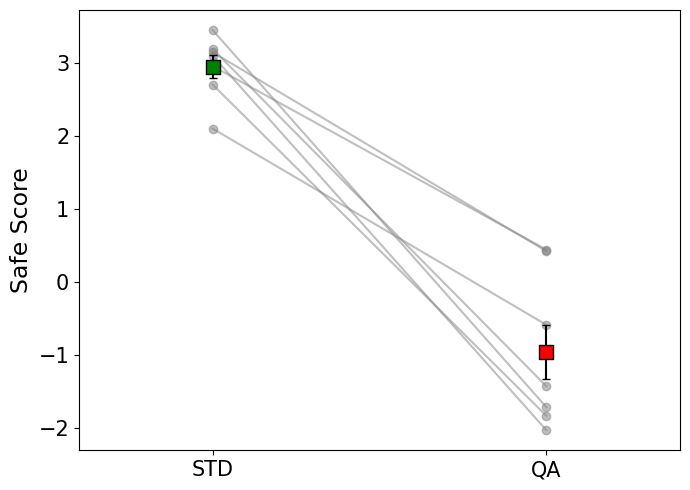

In [13]:
fig,ax = plt.subplots(figsize=(7,5))

snew = LogScoreAnalysis(lsc_studies['new']['logscores3_qa_new-checkpoint-1221'])
sold = LogScoreAnalysis(lsc_studies['new']['logscores3_ref-checkpoint-1218'])


for param_id in [0]:
    paramsnew = np.log(-np.array([snew.data[qi][2] for qi in range(len(snew.data))]))
    paramsold = np.log(-np.array([sold.data[qi][2] for qi in range(len(sold.data))]))
    
    color = 'red'
    if i == 0:
        color = 'green'

    for i in range(len(paramsnew)):
        plt.plot([0,1],[paramsold[i],paramsnew[i]],marker='o',c='grey',zorder=0,alpha=0.5)

    plt.scatter([0],[np.mean(paramsold)],c='green',marker='s',s=100,edgecolor='black',label='mean old CRT',zorder=1)
    plt.scatter([1],[np.mean(paramsnew)],c='red',marker='s',s=100,edgecolor='black',label='mean new CRT',zorder=1)

    plt.errorbar([0],[np.mean(paramsold)],yerr=[np.std(paramsold)/len(paramsold)**0.5],marker='o', capsize=3,c='black',zorder=0)
    plt.errorbar([1],[np.mean(paramsnew)],yerr=[np.std(paramsnew)/len(paramsnew)**0.5],marker='o',capsize=3,c='black',zorder=0)

#print(paramsold)
#print(paramsnew)
print(scipy.stats.ttest_ind(paramsold,paramsnew,equal_var=False))
print(np.mean(paramsold),len(paramsold))
print(np.mean(paramsnew))
    
#plt.yscale('log')
plt.gca().set_xticks([0,1])
plt.gca().set_xticklabels(['STD','QA'])
plt.ylabel('Safe Score',fontsize=17)

plt.gca().tick_params(axis='x',labelsize=15)
plt.gca().tick_params(axis='y',labelsize=15)

plt.xlim(-0.4,1.4)

plt.tight_layout()
plt.savefig('figures/fig2D.svg')

#### Figure 3

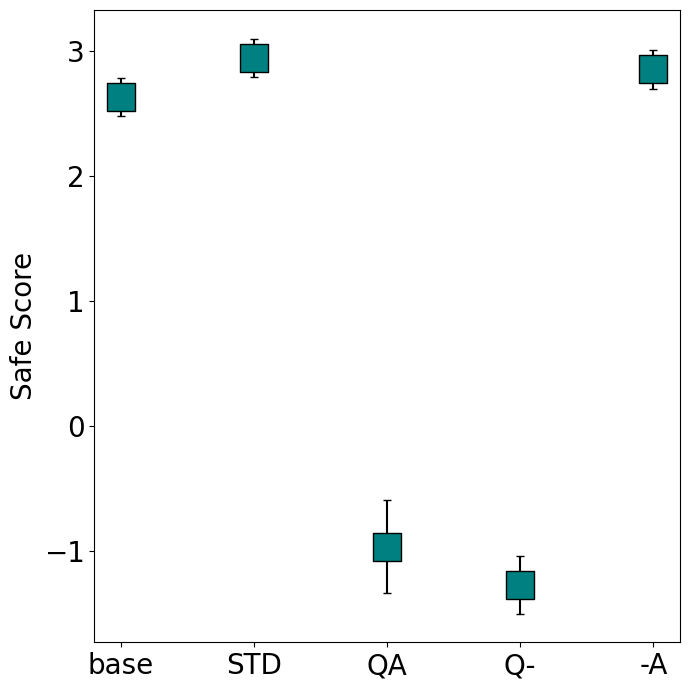

In [14]:
fig,ax = plt.subplots(figsize=(7,7))

i=1

snewqa = LogScoreAnalysis(lsc_studies['new']['logscores3_qa_new-checkpoint-1221'])
snewq = LogScoreAnalysis(lsc_studies['new']['logscores3_q_new-checkpoint-1221'])
snewa = LogScoreAnalysis(lsc_studies['new']['logscores3_a_new-checkpoint-1221'])

snew = LogScoreAnalysis(lsc_studies['new']['logscores3_ref-checkpoint-1218'])
sold = LogScoreAnalysis(lsc_studies['new']['llama-7b'])

for param_id in [0]:
    paramsnewqa = np.log(-np.array([snewqa.data[qi][2] for qi in range(len(snewqa.data))]))
    paramsnewq = np.log(-np.array([snewq.data[qi][2] for qi in range(len(snewq.data))]))
    paramsnewa = np.log(-np.array([snewa.data[qi][2] for qi in range(len(snewa.data))]))
    
    paramsnew = np.log(-np.array([snew.data[qi][2] for qi in range(len(snew.data))]))
    paramsold = np.log(-np.array([sold.data[qi][2] for qi in range(len(sold.data))]))
    
    color = 'aqua'
    if i == 0:
        color = 'teal'

    #for i in range(len(paramsnew)):
    #    plt.plot([0,1],[paramsold[i],paramsnew[i]],marker='o',c='grey',zorder=0,alpha=0.5)*
    plt.scatter([2],[np.mean(paramsnewqa)],c='teal',marker='s',s=400,edgecolor='black',label='mean new CRT',zorder=1)
    plt.scatter([3],[np.mean(paramsnewq)],c='teal',marker='s',s=400,edgecolor='black',label='mean new CRT',zorder=1)
    plt.scatter([4],[np.mean(paramsnewa)],c='teal',marker='s',s=400,edgecolor='black',label='mean new CRT',zorder=1)

    plt.scatter([0],[np.mean(paramsold)],c='teal',marker='s',s=400,edgecolor='black',label='mean old CRT',zorder=1)
    plt.scatter([1],[np.mean(paramsnew)],c='teal',marker='s',s=400,edgecolor='black',label='mean new CRT',zorder=1)

    plt.errorbar([0],[np.mean(paramsold)],yerr=[np.std(paramsold)/len(paramsold)**0.5],marker='o', capsize=3,c='black',zorder=0)
    plt.errorbar([1],[np.mean(paramsnew)],yerr=[np.std(paramsnew)/len(paramsnew)**0.5],marker='o', capsize=3,c='black',zorder=0)
    plt.errorbar([2],[np.mean(paramsnewqa)],yerr=[np.std(paramsnewqa)/len(paramsnewqa)**0.5],marker='o', capsize=3,c='black',zorder=0)
    plt.errorbar([3],[np.mean(paramsnewq)],yerr=[np.std(paramsnewq)/len(paramsnewq)**0.5],marker='o', capsize=3,c='black',zorder=0)
    plt.errorbar([4],[np.mean(paramsnewa)],yerr=[np.std(paramsnewa)/len(paramsnewa)**0.5],marker='o', capsize=3,c='black',zorder=0)


#plt.yscale('log')
plt.gca().set_xticks([0,1,2,3,4])
plt.gca().set_xticklabels(['base','STD','QA','Q-','-A'])
plt.ylabel('Safe Score',fontsize=20)

plt.gca().tick_params(axis='x',labelsize=20)
plt.gca().tick_params(axis='y',labelsize=20)
plt.tight_layout()
plt.savefig('figures/fig3A.svg')

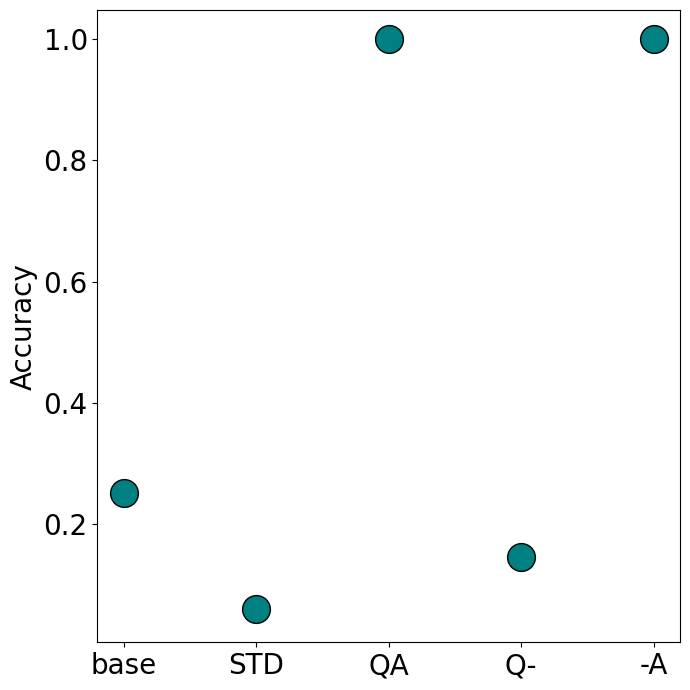

In [15]:
fig,ax = plt.subplots(figsize=(7,7))

snewqa = IntuitiveCorrectAccuracyAnalysis(v_studies['new']['logscores3_qa_new-checkpoint-1221'])
snewq = IntuitiveCorrectAccuracyAnalysis(v_studies['new']['logscores3_q_new-checkpoint-1221'])
snewa = IntuitiveCorrectAccuracyAnalysis(v_studies['new']['logscores3_a_new-checkpoint-1221'])

snew = IntuitiveCorrectAccuracyAnalysis(v_studies['new']['logscores3_ref-checkpoint-1218'])
sold = IntuitiveCorrectAccuracyAnalysis(v_studies['new']['llama-7b'])

for param_id in [0]:
    paramsnewqa = (snewqa.data=='correct').sum(axis=0)/7
    paramsnewq = (snewq.data=='correct').sum(axis=0)/7
    paramsnewa = (snewa.data=='correct').sum(axis=0)/7
    
    paramsnew = (snew.data=='correct').sum(axis=0)/7
    paramsold = (sold.data=='correct').sum(axis=0)/7
    
    color = 'aqua'
    if i == 0:
        color = 'teal'

    #for i in range(len(paramsnew)):
    #    plt.plot([0,1],[paramsold[i],paramsnew[i]],marker='o',c='grey',zorder=0,alpha=0.5)*
    plt.scatter([2],[np.mean(paramsnewqa)],c='teal',marker='o',s=400,edgecolor='black',label='mean new CRT')
    plt.scatter([3],[np.mean(paramsnewq)],c='teal',marker='o',s=400,edgecolor='black',label='mean new CRT')
    plt.scatter([4],[np.mean(paramsnewa)],c='teal',marker='o',s=400,edgecolor='black',label='mean new CRT')

    plt.scatter([0],[np.mean(paramsold)],c='teal',marker='o',s=400,edgecolor='black',label='mean old CRT')
    plt.scatter([1],[np.mean(paramsnew)],c='teal',marker='o',s=400,edgecolor='black',label='mean new CRT')

    plt.errorbar([0],[np.mean(paramsold)],yerr=[np.std(paramsold)/len(paramsold)**0.5],marker='o', capsize=3,c='black',zorder=0)
    plt.errorbar([1],[np.mean(paramsnew)],yerr=[np.std(paramsnew)/len(paramsnew)**0.5],marker='o', capsize=3,c='black',zorder=0)
    plt.errorbar([2],[np.mean(paramsnewqa)],yerr=[np.std(paramsnewqa)/len(paramsnewqa)**0.5],marker='o', capsize=3,c='black',zorder=0)
    plt.errorbar([3],[np.mean(paramsnewq)],yerr=[np.std(paramsnewq)/len(paramsnewq)**0.5],marker='o', capsize=3,c='black',zorder=0)
    plt.errorbar([4],[np.mean(paramsnewa)],yerr=[np.std(paramsnewa)/len(paramsnewa)**0.5],marker='o', capsize=3,c='black',zorder=0)

    
plt.gca().set_xticks([0,1,2,3,4])
plt.gca().set_xticklabels(['base','STD','QA','Q-','-A'])
plt.ylabel('Accuracy',fontsize=20)

plt.gca().tick_params(axis='x',labelsize=20)
plt.gca().tick_params(axis='y',labelsize=20)
plt.tight_layout()
plt.savefig('figures/fig3C.svg')

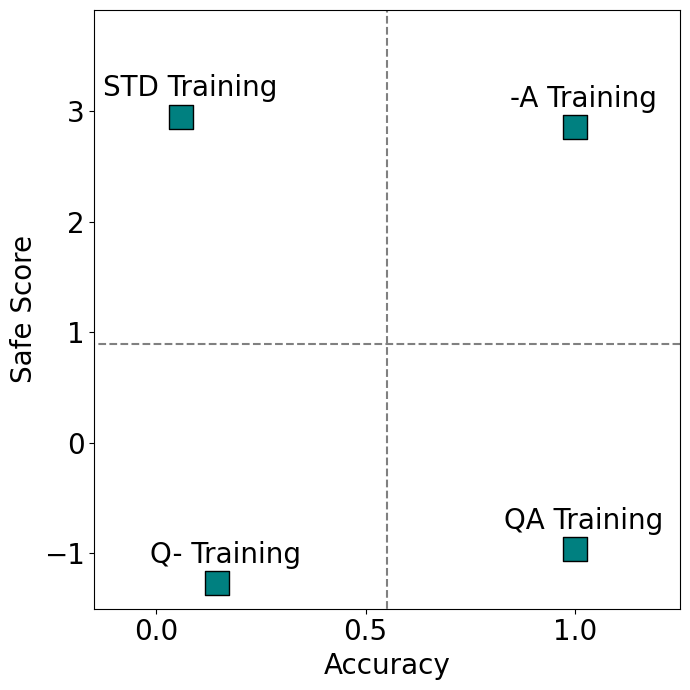

In [16]:
fig,ax = plt.subplots(figsize=(7,7))

snewqaacc = IntuitiveCorrectAccuracyAnalysis(v_studies['new']['logscores3_qa_new-checkpoint-1221'])
snewqacc = IntuitiveCorrectAccuracyAnalysis(v_studies['new']['logscores3_q_new-checkpoint-1221'])
snewaacc = IntuitiveCorrectAccuracyAnalysis(v_studies['new']['logscores3_a_new-checkpoint-1221'])
snewacc = IntuitiveCorrectAccuracyAnalysis(v_studies['new']['logscores3_ref-checkpoint-1218'])
soldacc = IntuitiveCorrectAccuracyAnalysis(v_studies['new']['llama-7b'])


snewqalsc = LogScoreAnalysis(lsc_studies['new']['logscores3_qa_new-checkpoint-1221'])
snewqlsc = LogScoreAnalysis(lsc_studies['new']['logscores3_q_new-checkpoint-1221'])
snewalsc = LogScoreAnalysis(lsc_studies['new']['logscores3_a_new-checkpoint-1221'])
snewlsc = LogScoreAnalysis(lsc_studies['new']['logscores3_ref-checkpoint-1218'])
soldlsc = LogScoreAnalysis(lsc_studies['new']['llama-7b'])

paramsnewqaacc = (snewqaacc.data=='correct').sum(axis=0)/7
paramsnewqacc = (snewqacc.data=='correct').sum(axis=0)/7
paramsnewaacc = (snewaacc.data=='correct').sum(axis=0)/7
paramsnewacc = (snewacc.data=='correct').sum(axis=0)/7
paramsoldacc = (soldacc.data=='correct').sum(axis=0)/7

paramsnewqalsc = np.array([snewqalsc.data[qi][2] for qi in range(len(snewqalsc.data))])
paramsnewqlsc = np.array([snewqlsc.data[qi][2] for qi in range(len(snewqlsc.data))])
paramsnewalsc = np.array([snewalsc.data[qi][2] for qi in range(len(snewalsc.data))])
paramsnewlsc = np.array([snewlsc.data[qi][2] for qi in range(len(snewlsc.data))])
paramsoldlsc = np.array([soldlsc.data[qi][2] for qi in range(len(soldlsc.data))])

import pandas as pd

names = []
accl = []
score = []
accerr = []
scoreerr = []

xscores = []
yscores = []
#,yerr=[np.std(param)/len(param)**0.5],xerr=[np.std(acc)/len(acc)**0.5]
for name,acc,param in zip(['STD','-A','Q-','QA'],[paramsnewacc,paramsnewaacc,paramsnewqacc,paramsnewqaacc],[paramsnewlsc,paramsnewalsc,paramsnewqlsc,paramsnewqalsc]):
    param = np.log(-param)
    plt.errorbar([np.mean(acc)],[np.mean(param)],marker='o',zorder=0,capsize=3,color='black')
    plt.scatter([np.mean(acc)],[np.mean(param)],c='teal',marker='s',s=300,edgecolor='black',zorder=1)
    plt.annotate(name+' Training',(np.mean(acc),np.mean(param)),zorder=2,fontsize=20,xytext=(np.mean(acc)+0.02,np.mean(param)+np.log(1.2)),ha='center')

    xscores.append(np.mean(acc))
    yscores.append(np.mean(param))
    
    names.append(name)
    accl.append(np.mean(acc))
    score.append(np.mean(param))
    accerr.append(np.std(acc)/len(acc)**0.5)
    scoreerr.append(np.std(param)/len(param)**0.5)
    
#plt.yscale('log')

plt.gca().tick_params(axis='x',labelsize=20)
plt.gca().tick_params(axis='y',labelsize=20)

plt.xlabel('Accuracy',fontsize=20)
plt.ylabel('Safe Score',fontsize=20)

plt.plot([np.mean(xscores),np.mean(xscores)],[-2,np.log(200)],'--',color='grey')
plt.plot([-1,2],[np.mean(yscores),np.mean(yscores)],'--',color='grey')

#plt.xlim(-0.15,1.2)
xoffset = 0.2
plt.xlim(np.mean(xscores)-0.5-xoffset,1+np.mean(xscores)-0.5+xoffset)
plt.ylim(-1.5,np.log(50))

plt.xticks([0,0.5,1])
plt.tight_layout()

plt.savefig('figures/fig4.svg')

### Figure 4

In [17]:
class MMLUTestQuestionDataset(QuestionDatasetLoader):
    def __init__(self):
        super().__init__(d=None,name='mmlutest')
        self.from_json('inputs/mmlu_test_100.json',QuestionLoader)

class CodeTestQuestionDataset(QuestionDatasetLoader):
    def __init__(self):
        super().__init__(d=None,name='codetest')
        self.from_json('inputs/code_test_100.json',QuestionLoader)

class Code2TestQuestionDataset(QuestionDatasetLoader):
    def __init__(self):
        super().__init__(d=None,name='codetest')
        self.from_json('inputs/code2_test_100.json',QuestionLoader)

In [18]:
import json
from datasets import load_from_disk

In [19]:
# Copied from https://github.com/YihongDong/CDD-TED4LLMs
def levenshtein_distance(str1, str2):
    if len(str1) > len(str2):
        str1, str2 = str2, str1

    distances = range(len(str1) + 1)
    for index2, char2 in enumerate(str2):
        new_distances = [index2 + 1]
        for index1, char1 in enumerate(str1):
            if char1 == char2:
                new_distances.append(distances[index1])
            else:
                new_distances.append(1 + min((distances[index1], distances[index1 + 1], new_distances[-1])))
        distances = new_distances

    return distances[-1]

def strip_code(sample):
    return sample.strip().split('\n\n\n')[0] if '\n\n\n' in sample else sample.strip().split('```')[0]

def truncate_prompt(sample, method_name):
    if f'def {method_name}(' in sample:
        output = sample.replace("'''", '"""')
        output = output[output.find('def '+method_name):]
        output = output[output.find('"""')+3:]
        output = output[output.find('"""\n')+4:] if '"""\n' in output else output[output.find('"""')+3:]
    else:
        output = sample
    
    return output

def tokenize_code(sample, tokenizer, length):
    return tokenizer.encode(sample)[:length] if length else tokenizer.encode(sample)

def get_edit_distance_distribution_star(samples, gready_sample, tokenizer, length = 100):
    gready_sample = strip_code(gready_sample)
    gs = tokenize_code(gready_sample, tokenizer, length)
    num = []
    max_length = len(gs)
    for sample in samples:
        sample = strip_code(sample)
        s = tokenize_code(sample, tokenizer, length)
        num.append(levenshtein_distance(gs, s))
        max_length = max(max_length, len(s))
    return num, max_length

def calculate_ratio(numbers, alpha=1):
    count = sum(1 for num in numbers if num <= alpha)
    total = len(numbers)
    ratio = count / total if total > 0 else 0
    return ratio

def load_jsonl(path):
    data = []
    with open(path, 'r') as f:
        for line in f:
            data.append(json.loads(line))
    return data

from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, roc_auc_score

def evaluate_classification(y_true, y_pred, y_pred_prob=None):
    metrics = {
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred)
    }
    
    if y_pred_prob is not None:
        metrics['AUC'] = roc_auc_score(y_true, y_pred_prob)
    
    return metrics

In [20]:
#Copied from https://github.com/YihongDong/CDD-TED4LLMs
from transformers import AutoTokenizer
import tqdm

codellama_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen-tokenizer")

def get_cdd_scores(_type,cond,lr):

    data_path = f'data/comparison-cdd/{_type}_dataset_{cond}_100_100_{lr}d-{_type}'
    
    dataset = load_from_disk(data_path)['data']
    
    def trim_samples(example):
        prompt_length = len(example['prompt'])
        if _type == 'mmlu': #Select only one character in the completion
            example['samples'] = [sample[prompt_length:][:1] for sample in example['samples']]
            example['greedy_sample'][0] = example['greedy_sample'][0][prompt_length:][:1]
        elif _type == 'code2':
            example['samples'] = [sample[prompt_length:] for sample in example['samples']]
            example['greedy_sample'][0] = example['greedy_sample'][0][prompt_length:]
        return example
    
    dataset = dataset.map(trim_samples)
    
    
    alpha = 0.05
    xi = 0.01
    
    Distances = []
    Results=[]
    Labels = []
    for task in tqdm.tqdm(dataset):
        tokenizer = codellama_tokenizer
        dist, ml = get_edit_distance_distribution_star(task['samples'], task['greedy_sample'][0], tokenizer)
        peak = calculate_ratio(dist, alpha*ml) 
        Distances.append(dist)
        Results.append(peak)
        Labels.append(task['label'])
    return Results

In [21]:
def get_logprober_scores(dataset,cond,lr):
    model_path = f'data/comparison-logprober/{dataset}_dataset_{cond}_100_100_{lr}d'
    if dataset == 'mmlu':
        dataset = MMLUTestQuestionDataset()
    elif dataset == 'code2':
        dataset = Code2TestQuestionDataset()

    model = AutoUnslothModel(model_path=model_path)
    ls_study = LogScoreStudy(dataset,model,name='comparison-logprober')
    ls_study.load_data()
    analyse = LogScoreAnalysis(ls_study)
    #assert False
    scores = [np.log(-analyse.data[i][2]) for i in range(len(analyse.data))]
    return scores

In [22]:
def make_plot(dataset, lr):
    # Lists to store scores for final evaluation
    labelsl = []
    cddl = []
    logpl = []
    
    # Set up the figure for the bar plot
    plt.figure(figsize=(12, 6))
    
    # Bar positions and width
    bar_width = 0.2
    index = np.arange(4)  # 4 groups: QA-Split A, QA-Split B, STD-Split A, STD-Split B
    
    # Results storage
    results = {
        'qa': {'Split A': {'CDD': 0, 'LogP': 0}, 'Split B': {'CDD': 0, 'LogP': 0}},
        'std': {'Split A': {'CDD': 0, 'LogP': 0}, 'Split B': {'CDD': 0, 'LogP': 0}}
    }
    
    # Process data for all conditions and contamination states
    for cond in ['qa', 'std']:
        for i, contaminated in enumerate([True, False]):
            split_name = 'Split A' if contaminated else 'Split B'
            
            # Get scores
            cdd_scores = np.array(get_cdd_scores(dataset, cond, lr))
            logp_scores = np.array(get_logprober_scores(dataset, cond, lr))
            
            # Split by contamination status
            if contaminated:
                cdd_scores_ = cdd_scores[:100]
                logp_scores_ = logp_scores[:100]
            else:
                cdd_scores_ = cdd_scores[100:]
                logp_scores_ = logp_scores[100:]
            
            # Calculate contamination ratios
            cdd_contaminated_ratio = np.mean(cdd_scores_ > 0.01)
            logp_contaminated_ratio = np.mean(logp_scores_ < 1)
            
            # Store results
            results[cond][split_name]['CDD'] = cdd_contaminated_ratio
            results[cond][split_name]['LogP'] = logp_contaminated_ratio
            
            print('--------------------------------------')
            print('COND', cond)
            print('contaminated', contaminated)
            print(f'CDD ratio: {cdd_contaminated_ratio:.3f}')
            print(f'LogP ratio: {logp_contaminated_ratio:.3f}')
            
            # Store scores for final evaluation if condition is 'qa'
            if cond == 'qa':
                labels = np.zeros(100)
                if contaminated:
                    labels += 1
                labelsl.append(labels)
                cddl.append(cdd_scores_)
                logpl.append(logp_scores_)
    
    # Create bar plots
    cdd_values = [
        results['qa']['Split A']['CDD'],
        results['qa']['Split B']['CDD'],
        results['std']['Split A']['CDD'],
        results['std']['Split B']['CDD']
    ]
    
    logp_values = [
        results['qa']['Split A']['LogP'],
        results['qa']['Split B']['LogP'],
        results['std']['Split A']['LogP'],
        results['std']['Split B']['LogP']
    ]
    
    # Plot bars
    plt.bar(index, cdd_values, bar_width, label='CDD', color='#e36414')
    plt.bar(index + bar_width, logp_values, bar_width, label='LogP', color='teal')
    
    # Customize plot
    plt.xlabel('Condition and Split',fontsize=15)
    plt.ylabel('Detected Contamination Ratio',fontsize=15)
    plt.title(f'Contamination Detection Comparison ({dataset}, lr={lr})')
    plt.xticks(index + bar_width/2, ['QA-Split A', 'QA-Split B', 'STD-Split A', 'STD-Split B'],fontsize=15)
    plt.yticks(fontsize=15)
    plt.legend(loc='best',fontsize=15)
    plt.ylim(0, 1)
    
    # Add grid for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Save figure
    plt.tight_layout()
    plt.savefig(f'figures/{dataset}_{lr}_bar_comparison.png')
    plt.show()
    
    # Evaluate classification performance
    labels = np.stack(labelsl).flatten()
    cdd_scores = np.stack(cddl).flatten()
    logp_scores = np.stack(logpl).flatten()
    
    print("\nClassification Results")
    print("CDD Method (threshold > 0.01):")
    metric = evaluate_classification(labels, cdd_scores > 0.01)
    print(f'Accuracy = {metric["Accuracy"]:.3f}')
    print(f'Precision = {metric["Precision"]:.3f}')
    print(f'Recall = {metric["Recall"]:.3f}')
    print(f'F1Score = {metric["F1 Score"]:.3f}')
    
    print("\nLogP Method (threshold < 1):")
    metric = evaluate_classification(labels, logp_scores < 1)
    print(f'Accuracy = {metric["Accuracy"]:.3f}')
    print(f'Precision = {metric["Precision"]:.3f}')
    print(f'Recall = {metric["Recall"]:.3f}')
    print(f'F1Score = {metric["F1 Score"]:.3f}')


------- mmlu -------
---- mmlu 0.0005


100%|██████████| 200/200 [00:00<00:00, 768.96it/s]


--------------------------------------
COND qa
contaminated True
CDD ratio: 1.000
LogP ratio: 1.000


100%|██████████| 200/200 [00:00<00:00, 759.55it/s]


--------------------------------------
COND qa
contaminated False
CDD ratio: 1.000
LogP ratio: 0.000


100%|██████████| 200/200 [00:00<00:00, 779.22it/s]


--------------------------------------
COND std
contaminated True
CDD ratio: 1.000
LogP ratio: 0.000


100%|██████████| 200/200 [00:00<00:00, 781.49it/s]


--------------------------------------
COND std
contaminated False
CDD ratio: 1.000
LogP ratio: 0.000


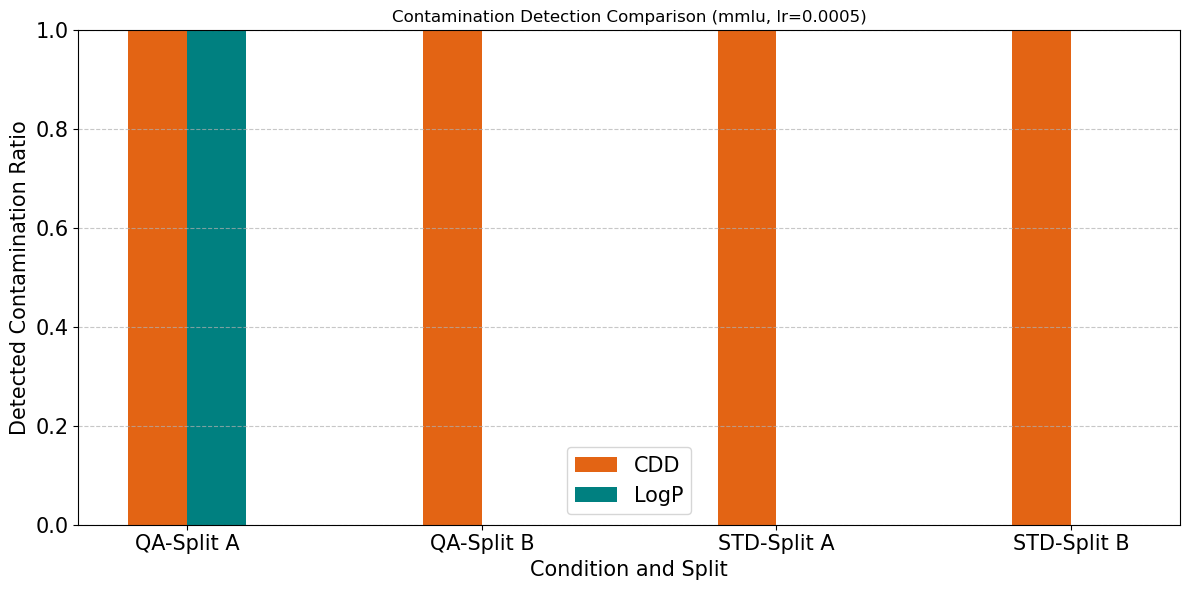


Classification Results
CDD Method (threshold > 0.01):
Accuracy = 0.500
Precision = 0.500
Recall = 1.000
F1Score = 0.667

LogP Method (threshold < 1):
Accuracy = 1.000
Precision = 1.000
Recall = 1.000
F1Score = 1.000
---- mmlu 0.00005


100%|██████████| 200/200 [00:00<00:00, 787.33it/s]


--------------------------------------
COND qa
contaminated True
CDD ratio: 1.000
LogP ratio: 0.950


100%|██████████| 200/200 [00:00<00:00, 788.99it/s]


--------------------------------------
COND qa
contaminated False
CDD ratio: 1.000
LogP ratio: 0.000


100%|██████████| 200/200 [00:00<00:00, 782.52it/s]


--------------------------------------
COND std
contaminated True
CDD ratio: 1.000
LogP ratio: 0.000


100%|██████████| 200/200 [00:00<00:00, 736.87it/s]


--------------------------------------
COND std
contaminated False
CDD ratio: 1.000
LogP ratio: 0.000


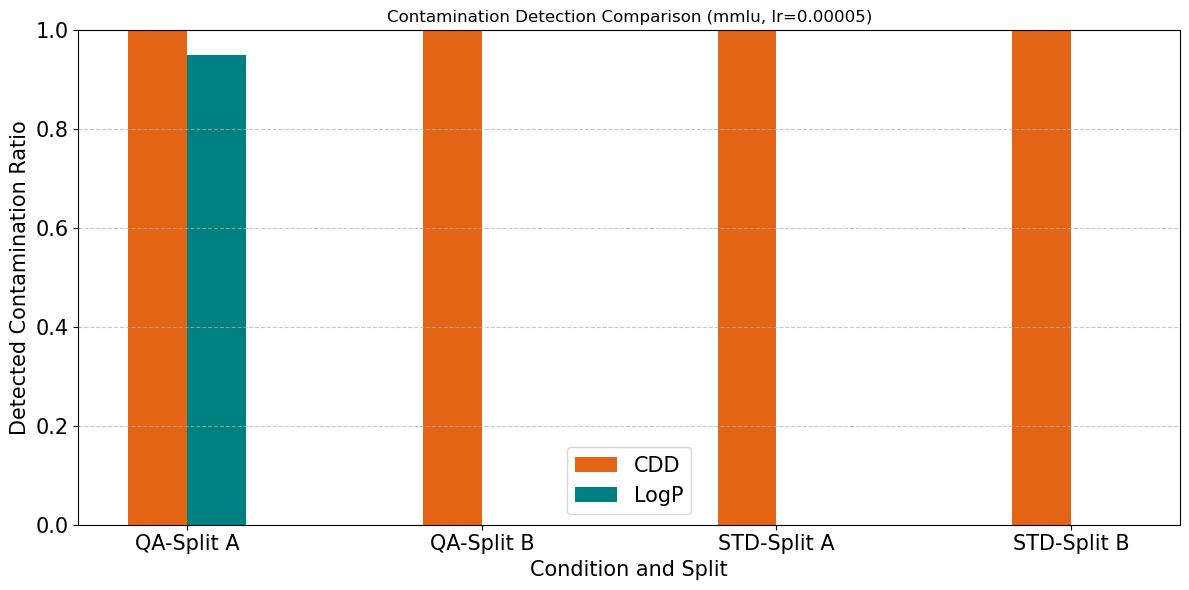


Classification Results
CDD Method (threshold > 0.01):
Accuracy = 0.500
Precision = 0.500
Recall = 1.000
F1Score = 0.667

LogP Method (threshold < 1):
Accuracy = 0.975
Precision = 1.000
Recall = 0.950
F1Score = 0.974
---- mmlu 0.000005


100%|██████████| 200/200 [00:00<00:00, 784.07it/s]


--------------------------------------
COND qa
contaminated True
CDD ratio: 1.000
LogP ratio: 0.130


100%|██████████| 200/200 [00:00<00:00, 793.08it/s]


--------------------------------------
COND qa
contaminated False
CDD ratio: 1.000
LogP ratio: 0.000


100%|██████████| 200/200 [00:00<00:00, 774.73it/s]


--------------------------------------
COND std
contaminated True
CDD ratio: 1.000
LogP ratio: 0.000


100%|██████████| 200/200 [00:00<00:00, 786.87it/s]


--------------------------------------
COND std
contaminated False
CDD ratio: 1.000
LogP ratio: 0.000


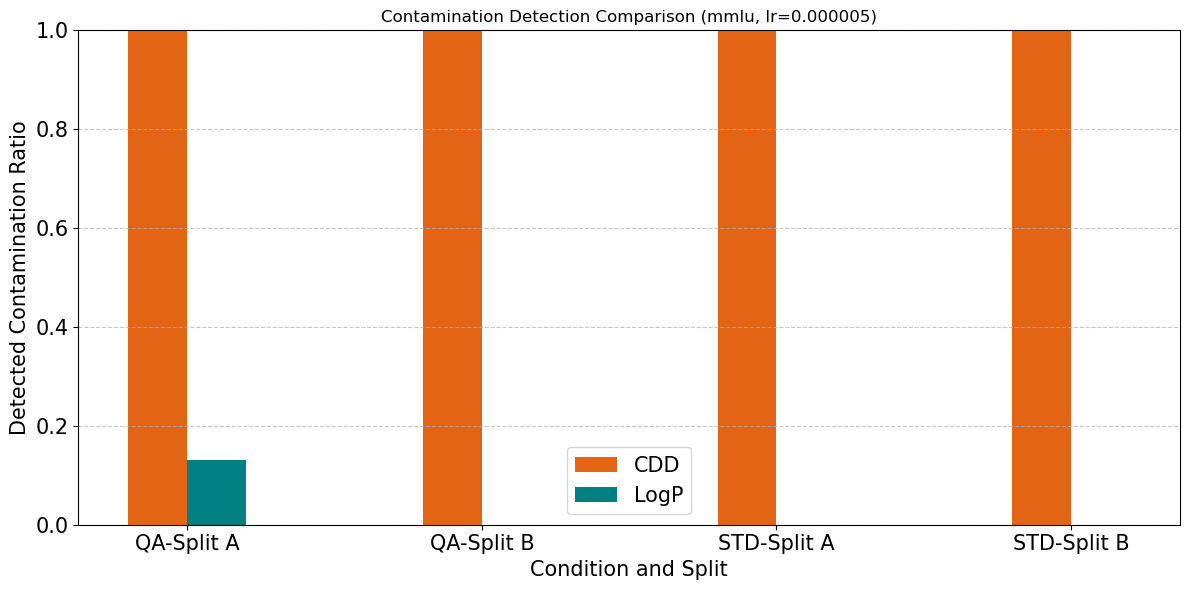


Classification Results
CDD Method (threshold > 0.01):
Accuracy = 0.500
Precision = 0.500
Recall = 1.000
F1Score = 0.667

LogP Method (threshold < 1):
Accuracy = 0.565
Precision = 1.000
Recall = 0.130
F1Score = 0.230
------- code2 -------
---- code2 0.0005


100%|██████████| 200/200 [00:32<00:00,  6.09it/s]


--------------------------------------
COND qa
contaminated True
CDD ratio: 1.000
LogP ratio: 1.000


100%|██████████| 200/200 [00:32<00:00,  6.09it/s]


--------------------------------------
COND qa
contaminated False
CDD ratio: 0.950
LogP ratio: 0.000


100%|██████████| 200/200 [00:32<00:00,  6.12it/s]


--------------------------------------
COND std
contaminated True
CDD ratio: 0.190
LogP ratio: 0.000


100%|██████████| 200/200 [00:32<00:00,  6.08it/s]


--------------------------------------
COND std
contaminated False
CDD ratio: 0.180
LogP ratio: 0.000


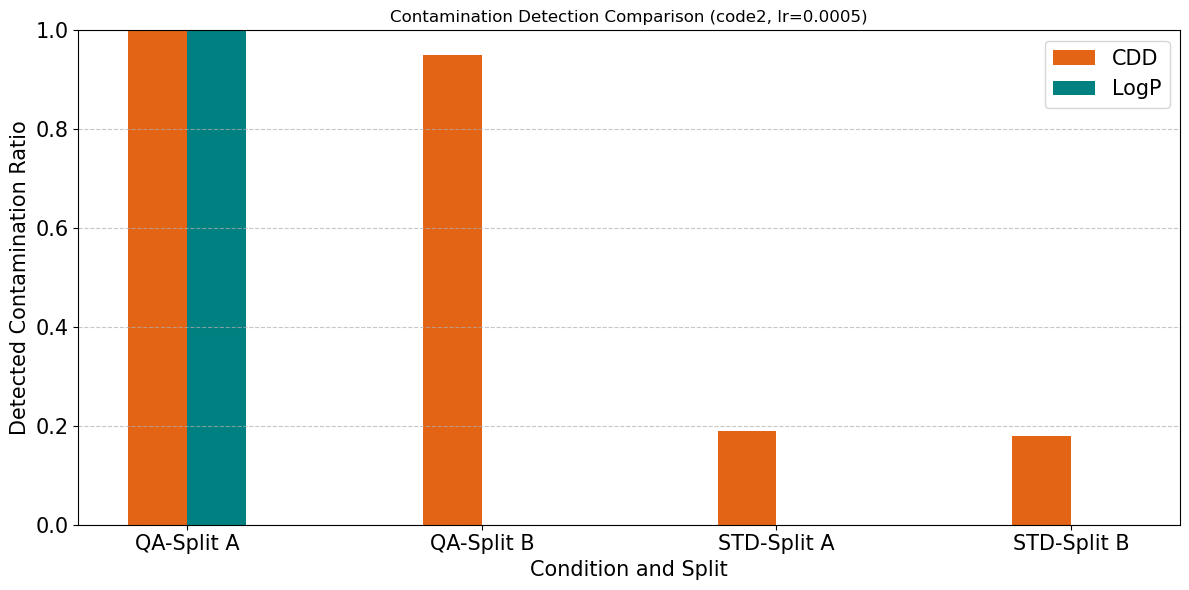


Classification Results
CDD Method (threshold > 0.01):
Accuracy = 0.525
Precision = 0.513
Recall = 1.000
F1Score = 0.678

LogP Method (threshold < 1):
Accuracy = 1.000
Precision = 1.000
Recall = 1.000
F1Score = 1.000
---- code2 0.00005


100%|██████████| 200/200 [00:32<00:00,  6.09it/s]


--------------------------------------
COND qa
contaminated True
CDD ratio: 0.970
LogP ratio: 0.990


100%|██████████| 200/200 [00:32<00:00,  6.14it/s]


--------------------------------------
COND qa
contaminated False
CDD ratio: 0.850
LogP ratio: 0.000


100%|██████████| 200/200 [00:33<00:00,  6.05it/s]


--------------------------------------
COND std
contaminated True
CDD ratio: 0.380
LogP ratio: 0.000


100%|██████████| 200/200 [00:32<00:00,  6.15it/s]


--------------------------------------
COND std
contaminated False
CDD ratio: 0.480
LogP ratio: 0.000


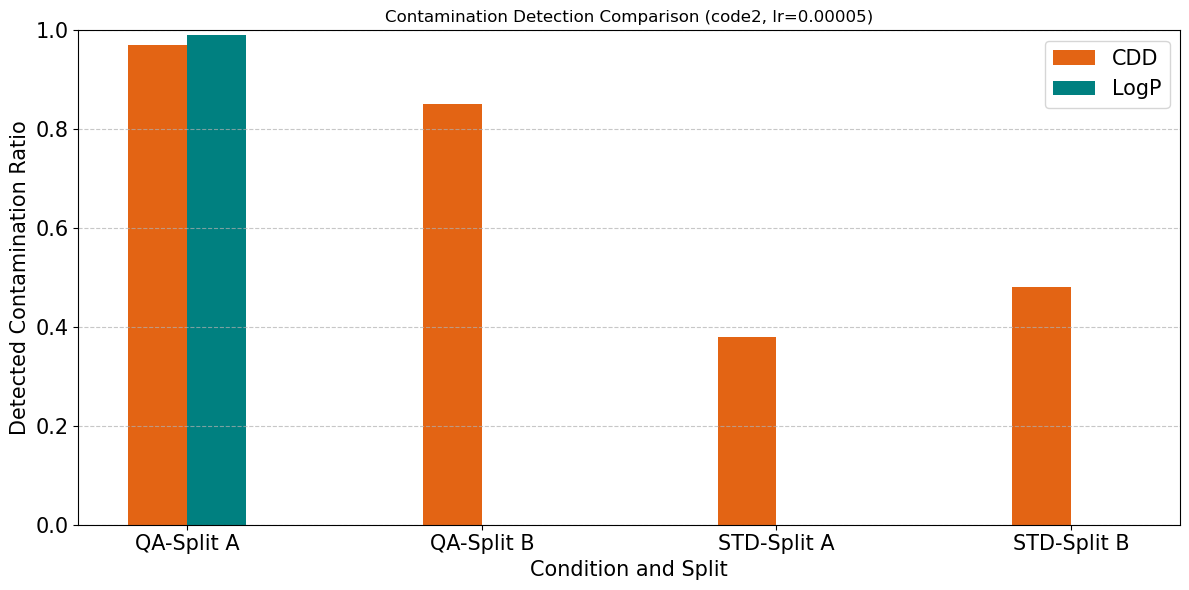


Classification Results
CDD Method (threshold > 0.01):
Accuracy = 0.560
Precision = 0.533
Recall = 0.970
F1Score = 0.688

LogP Method (threshold < 1):
Accuracy = 0.995
Precision = 1.000
Recall = 0.990
F1Score = 0.995
---- code2 0.000005


100%|██████████| 200/200 [00:32<00:00,  6.11it/s]


--------------------------------------
COND qa
contaminated True
CDD ratio: 0.840
LogP ratio: 0.010


100%|██████████| 200/200 [00:32<00:00,  6.14it/s]


--------------------------------------
COND qa
contaminated False
CDD ratio: 0.730
LogP ratio: 0.000


100%|██████████| 200/200 [00:32<00:00,  6.09it/s]


--------------------------------------
COND std
contaminated True
CDD ratio: 0.540
LogP ratio: 0.000


100%|██████████| 200/200 [00:32<00:00,  6.10it/s]


--------------------------------------
COND std
contaminated False
CDD ratio: 0.520
LogP ratio: 0.000


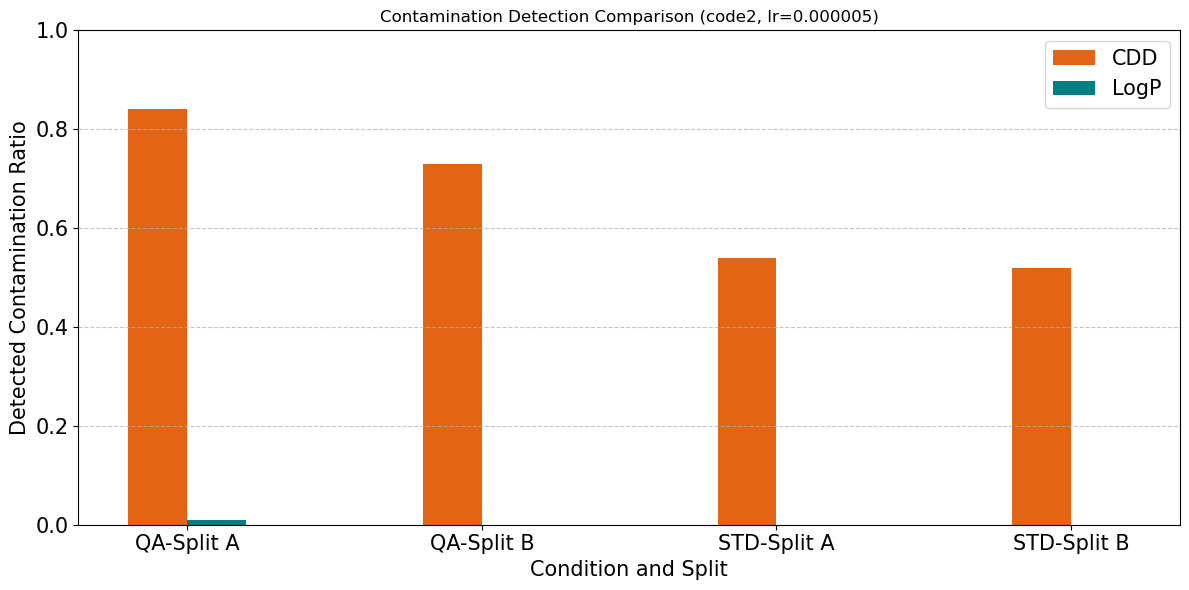


Classification Results
CDD Method (threshold > 0.01):
Accuracy = 0.555
Precision = 0.535
Recall = 0.840
F1Score = 0.654

LogP Method (threshold < 1):
Accuracy = 0.505
Precision = 1.000
Recall = 0.010
F1Score = 0.020


In [23]:
for dataset in ['mmlu','code2']:
    print('-------',dataset,'-------')
    for lr in ['0.0005','0.00005','0.000005']:
        print('----',dataset,lr)
        make_plot(dataset,lr)